In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

# 1.LOAD DATA
# ====================================
df = pd.read_csv("cleaning.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)


Shape: (4424, 41)

Data Types:
marital_status                                    int64
application_mode                                  int64
application_order                                 int64
course                                            int64
daytime/evening_attendance                        int64
previous_qualification                            int64
previous_qualification_grade                    float64
nacionality                                       int64
mothers_qualification                             int64
fathers_qualification                             int64
mothers_occupation                                int64
fathers_occupation                                int64
admission_grade                                 float64
displaced                                         int64
educational_special_needs                         int64
debtor                                            int64
tuition_fees_up_to_date                           int64
gender           


Churn Distribution (%):
churn_status
Retained    49.932188
Churn       32.120253
Active      17.947559
Name: proportion, dtype: float64


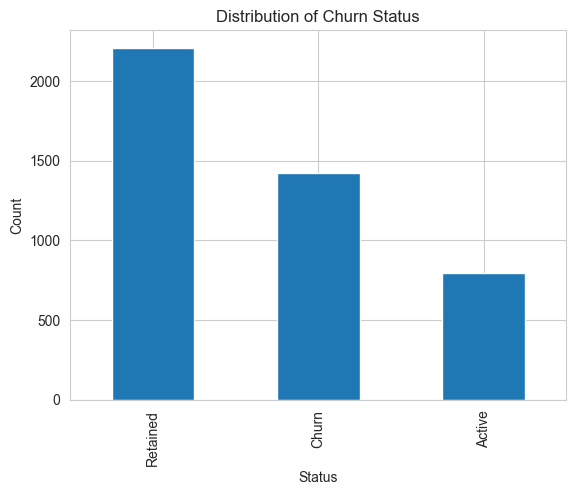

In [6]:
# 2. TARGET DISTRIBUTION
# =====================================
import os
os.makedirs("images", exist_ok=True)

print("\nChurn Distribution (%):")
print(df["churn_status"].value_counts(normalize=True) * 100)

plt.figure()
df["churn_status"].value_counts().plot(kind="bar")
plt.title("Distribution of Churn Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


Approval Rate by Status:
churn_status
Active      0.693398
Churn       0.357927
Retained    0.933474
Name: approval_rate, dtype: float64


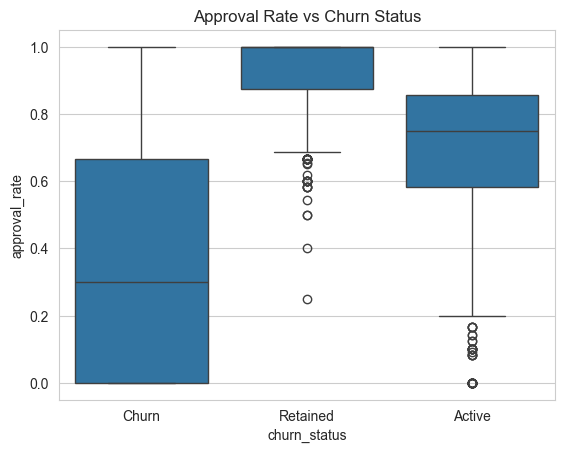


Total Units Approved by Status:
churn_status
Active       8.376574
Churn        4.481351
Retained    12.304663
Name: total_units_approved, dtype: float64


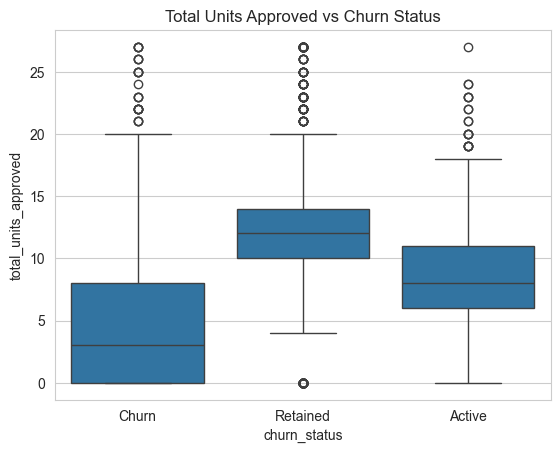

In [8]:
# 3.ACADEMIC PERFORMANCE ANALYSIS
# ====================================

import os
os.makedirs("images", exist_ok=True)

print("\nApproval Rate by Status:")
print(df.groupby("churn_status")["approval_rate"].mean())

plt.figure()
sns.boxplot(x="churn_status", y="approval_rate", data=df)
plt.title("Approval Rate vs Churn Status")
plt.savefig("Appproval Rate vs Churn Status.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nTotal Units Approved by Status:")
print(df.groupby("churn_status")["total_units_approved"].mean())

plt.figure()
sns.boxplot(x="churn_status", y="total_units_approved", data=df)
plt.title("Total Units Approved vs Churn Status")
plt.savefig("Total Units Approved vs Churn Status.png", dpi=300, bbox_inches="tight")
plt.show()


Payment Risk vs Churn (%):
churn_status     Active      Churn   Retained
payment_risk                                 
0             18.741412  23.825227  57.433361
1             14.267516  70.573248  15.159236


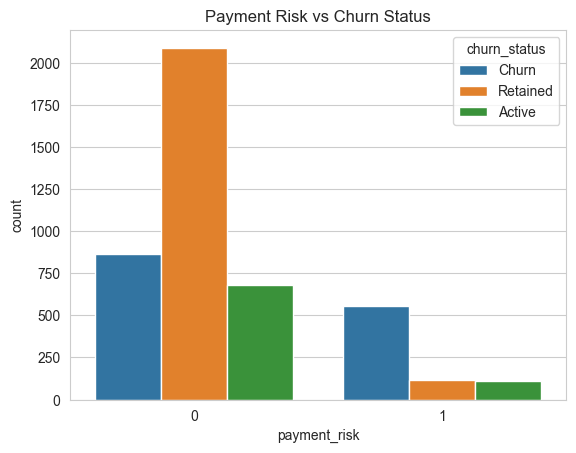


Debtor vs Churn (%):
churn_status     Active      Churn   Retained
debtor                                       
0             17.954603  28.283601  53.761795
1             17.892644  62.027833  20.079523


In [9]:
# 4. FINANCIAL RISK ANALYSIS
#=========================================

import os
os.makedirs("images", exist_ok=True)

print("\nPayment Risk vs Churn (%):")
print(pd.crosstab(df["payment_risk"], df["churn_status"], normalize="index") * 100)

plt.figure()
sns.countplot(x="payment_risk", hue="churn_status", data=df)
plt.title("Payment Risk vs Churn Status")
plt.savefig("Payment Risk vs Churn Status.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nDebtor vs Churn (%):")
print(pd.crosstab(df["debtor"], df["churn_status"], normalize="index") * 100)


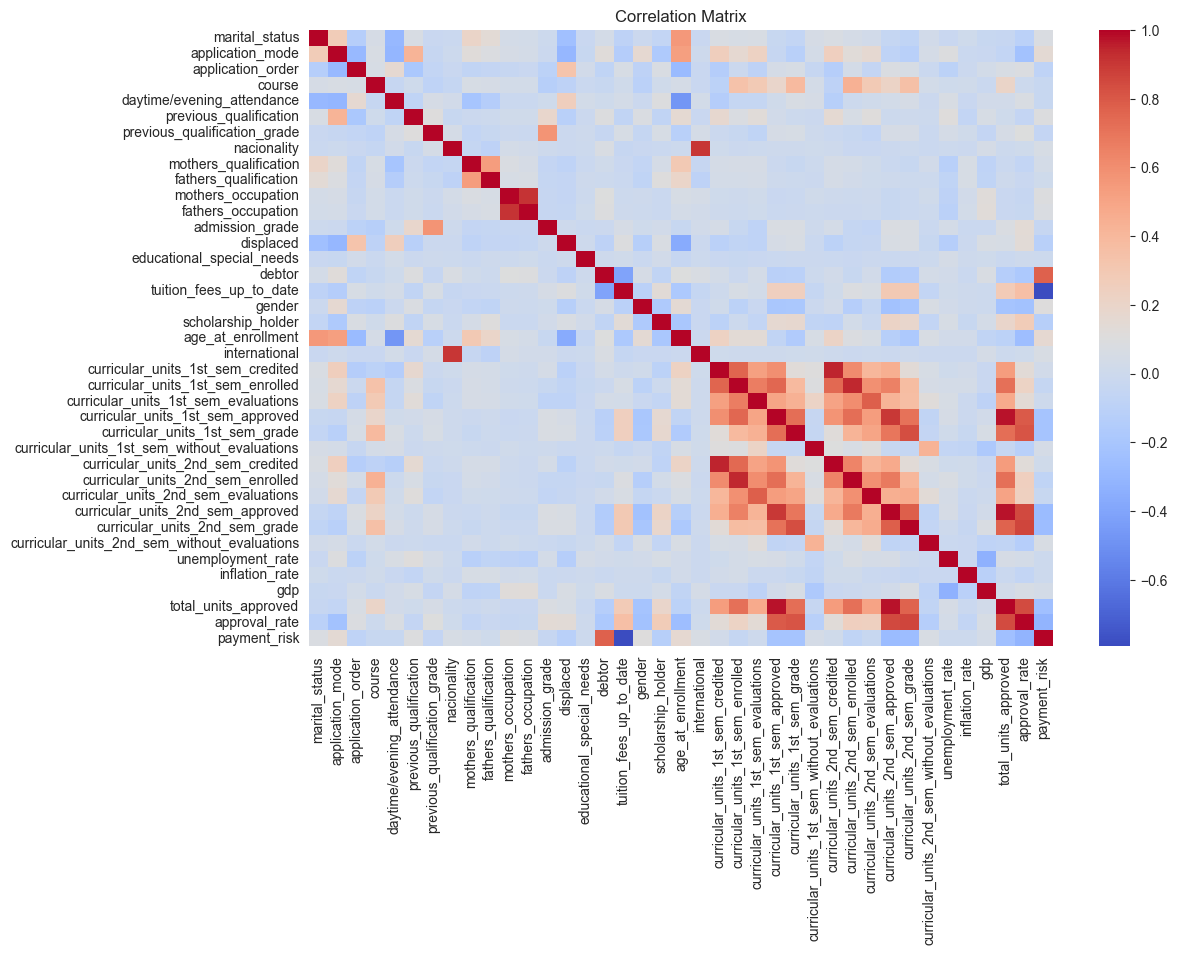

In [10]:
# 5. CORRELATION ANALYSIS
#======================================
import os
os.makedirs("images", exist_ok=True)

numerical_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
corr = numerical_cols.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Correlation Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# 6. HIGH RISK SEGMENT CHECK
#============================================

high_risk = df[
    (df["approval_rate"] < 0.5) &
    (df["payment_risk"] == 1)
]

print("\nHigh Risk Students Distribution:")
print(high_risk ["churn_status"].value_counts(normalize=True) * 100)




High Risk Students Distribution:
churn_status
Churn     93.678161
Active     6.321839
Name: proportion, dtype: float64


In [12]:
# 7. SUMMARY INSIGHT METRICS
# =====================================

print("\n=== KPI SUMMARY ===")
print("Total Students:", len(df))
print("Dropout Rate:",
      round((df["churn_status"] == "Churn").mean() * 100, 2), "%")
print("Average Approval Rate:",
      round(df["approval_rate"].mean(), 2))
print("Payment Risk Rate:",
      round(df["payment_risk"].mean() * 100, 2), "%")

print("\nEDA Completed Successfully.")


=== KPI SUMMARY ===
Total Students: 4424
Dropout Rate: 32.12 %
Average Approval Rate: 0.71
Payment Risk Rate: 17.74 %

EDA Completed Successfully.
